In [1]:
# Load Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("house_price.csv")
data.head(10)

,area,bedrooms,bathrooms,floors,location_score,age,price
0,3674,4,3,2,3,2,1407251
1,1360,2,2,1,4,17,455386
2,1794,3,2,1,9,13,823254
3,1630,4,3,1,7,19,695184
4,1595,5,3,1,1,17,652287
5,3592,1,2,2,4,9,1149221
6,2138,5,2,2,4,24,816964
7,2669,4,1,2,9,1,1228684
8,966,4,2,2,6,24,439592
9,1738,4,2,1,9,28,676653


In [3]:
data.shape # row, column

(500, 7)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   area            500 non-null    int64
 1   bedrooms        500 non-null    int64
 2   bathrooms       500 non-null    int64
 3   floors          500 non-null    int64
 4   location_score  500 non-null    int64
 5   age             500 non-null    int64
 6   price           500 non-null    int64
dtypes: int64(7)
memory usage: 27.5 KB


In [5]:
# check null values
data.isnull().sum()

area              0
bedrooms          0
bathrooms         0
floors            0
location_score    0
age               0
price             0
dtype: int64

There is no missing/null values in this House price dataset

In [6]:
data.describe()

,area,bedrooms,bathrooms,floors,location_score,age,price
count,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,5.000000e+02
mean,2319.38400,3.052000,2.000000,1.476000,4.980000,14.950000,8.563349e+05
std,1003.67328,1.462043,0.818131,0.499924,2.581653,8.633457,3.300082e+05
min,501.00000,1.000000,1.000000,1.000000,1.000000,0.000000,6.540000e+04
25%,1478.75000,2.000000,1.000000,1.000000,3.000000,7.000000,6.164570e+05
50%,2297.50000,3.000000,2.000000,1.000000,5.000000,16.000000,8.723660e+05
75%,3208.00000,4.000000,3.000000,2.000000,7.000000,22.000000,1.108168e+06
max,3999.00000,5.000000,3.000000,2.000000,9.000000,29.000000,1.594013e+06


In [7]:
data.duplicated().sum()

0

No duplicate records were found in the dataset.

In [8]:
data.columns

Index(['area', 'bedrooms', 'bathrooms', 'floors', 'location_score', 'age',
       'price'],
      dtype='object')

# Scatter Plot Analysis

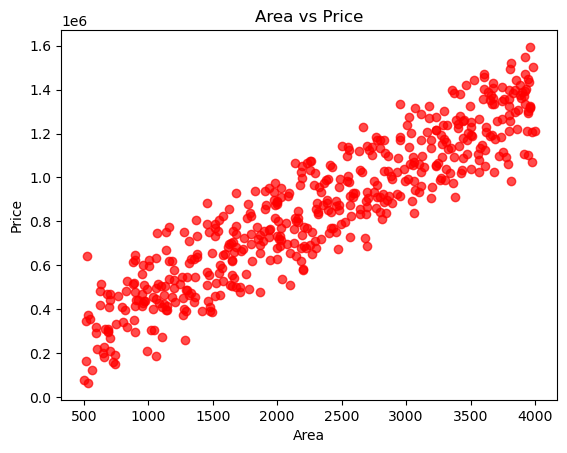

In [9]:
plt.scatter(data["area"],data["price"], color= "red", alpha=0.7)
plt.title("Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

House Price Increase as Area Increases, there is a strong relationship between area and price.

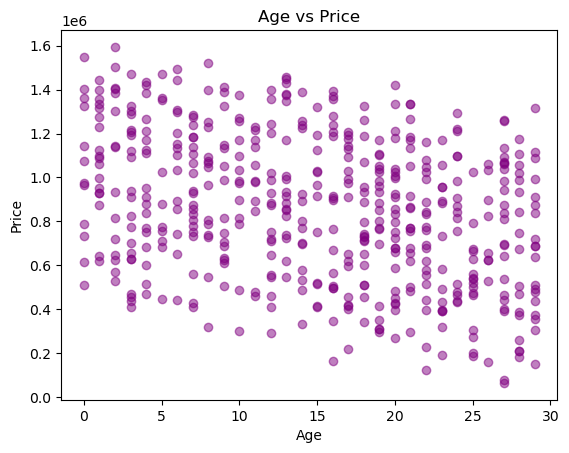

In [10]:
plt.scatter(data["age"],data["price"], color= "purple", alpha=0.5)
plt.title("Age vs Price")
plt.xlabel("Age")
plt.ylabel("Price")
plt.show()

Older houses have lower price compare to new houses.

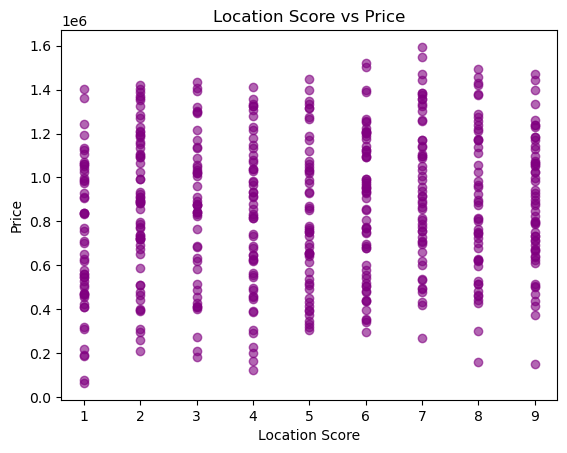

In [11]:
plt.scatter(data["location_score"],data["price"], color= "purple", alpha=0.6)
plt.title("Location Score vs Price")
plt.xlabel("Location Score")
plt.ylabel("Price")
plt.show()

Here Houses with higher location score have higher prices.

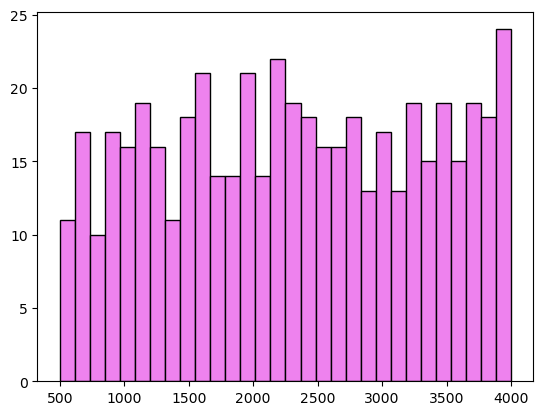

In [12]:
plt.hist(data["area"], bins=30, edgecolor="black", color= "violet")
plt.show()

Most houses are concentrated between medium to large area ranges.

In [13]:
count_b = data.groupby("bedrooms").size()
count_b

bedrooms
1    101
2    101
3     86
4     95
5    117
dtype: int64

In [14]:
count_b = data.groupby(['bedrooms','floors']).size().unstack()
count_b

floors,1,2
bedrooms,,
1,48,53
2,57,44
3,46,40
4,50,45
5,61,56


In [15]:
# floor 1 have 48 house with 1 bedroom and floor 2 have 53 house

<Axes: xlabel='bedrooms'>

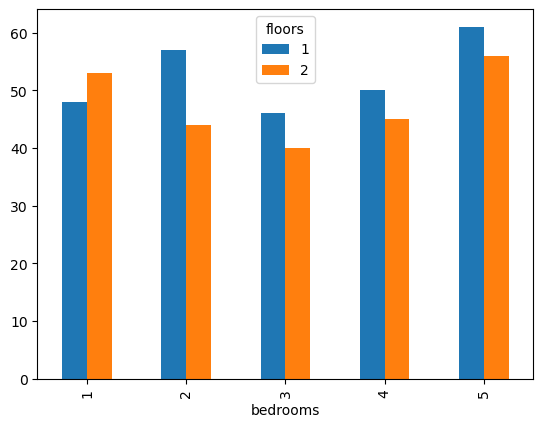

In [16]:
count_b.plot(kind="bar")

Houses with more bedrooms generally have higher floor distribution.

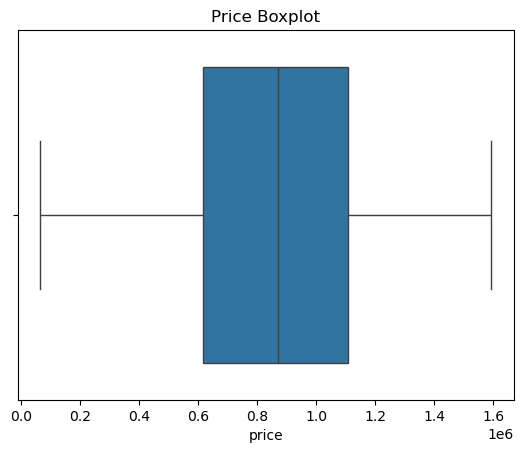

In [17]:
sns.boxplot(x=data["price"])
plt.title("Price Boxplot")
plt.show()

House prices are widely distributed with some high-priced properties.

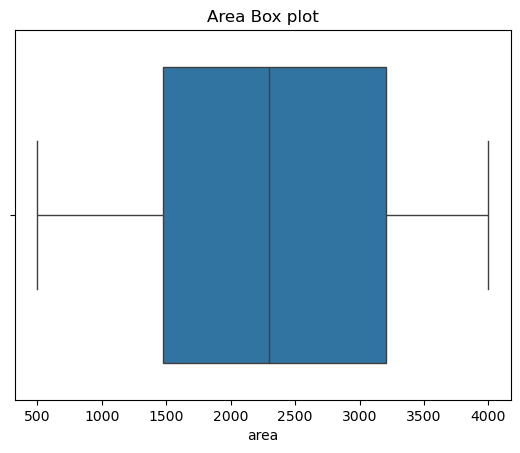

In [18]:
sns.boxplot(x=data["area"])
plt.title("Area Box plot")
plt.show()

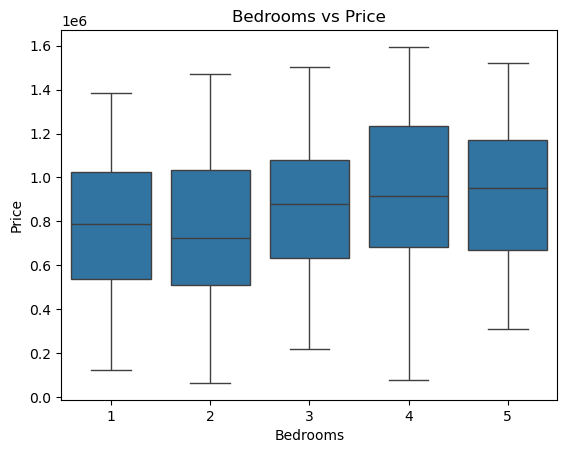

In [19]:
sns.boxplot(x="bedrooms", y="price", data=data)
plt.title("Bedrooms vs Price")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.show()

Houses with more bedrooms generally show higher median prices.

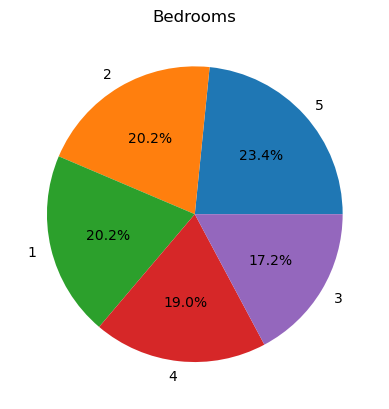

In [20]:
bedroom = data["bedrooms"].value_counts()

plt.pie(bedroom, labels=bedroom.index, autopct="%1.1f%%")
plt.title("Bedrooms")
plt.show()

Bedroom distribution is fairly balanced across different house types.

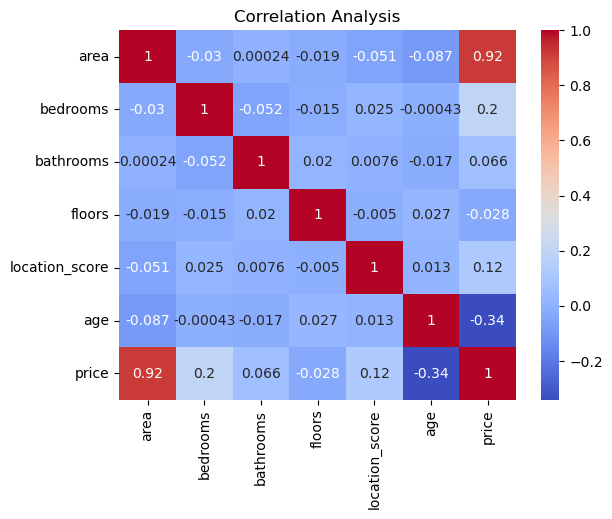

In [22]:
corr = data[['area', 'bedrooms', 'bathrooms', 'floors', 'location_score', 'age','price']].corr()

sns.heatmap(corr,annot=True, cmap="coolwarm")
plt.title("Correlation Analysis")
plt.show()

Area has the strongest positive correlation with price, while age has a negative correlation with price.

#### The analysis shows that area and location score significantly influence house prices, while age negatively affects pricing. Area was found to be the strongest predictor of house price.